# Cyclistic Case Study  
## Google Data Analytics Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os                           # os means Operating System Module. This lets Python talk to your computer — like reading folder contents, finding files etc.
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Path to your CSV files
folder_path = r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\CSV files'   # The r stands for raw, meaning "don't interpret backslashes as special characters."

# Load all CSV files
# This is List Comprehension
# Note that the variable all_files only contains files names and not the actual data
 
all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]      # This is list comprehension

print(f"Found {len(all_files)} files:")                              # f stands for fomatted string.
for f in all_files:
    print(" -", f)

Found 12 files:
 - 202501-divvy-tripdata.csv
 - 202502-divvy-tripdata.csv
 - 202503-divvy-tripdata.csv
 - 202504-divvy-tripdata.csv
 - 202505-divvy-tripdata.csv
 - 202506-divvy-tripdata.csv
 - 202507-divvy-tripdata.csv
 - 202508-divvy-tripdata.csv
 - 202509-divvy-tripdata.csv
 - 202510-divvy-tripdata.csv
 - 202511-divvy-tripdata.csv
 - 202512-divvy-tripdata.csv


### Combine all the CSV files into one dataframe

In [3]:
df_list = []                                                   # Creating an empty list
for file in all_files:
    temp = pd.read_csv(os.path.join(folder_path, file))
    df_list.append(temp)                                       # Putting all CSV files into single list dataframe
    print(f"Loaded: {file} — {len(temp)} rows")

# Now creating one single CSV file
df = pd.concat(df_list, ignore_index = True)            # ignore_index = True --> After combining the DataFrames, create a brand new index starting from 0."

print(f"\nTotal rows combined: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Loaded: 202501-divvy-tripdata.csv — 138689 rows
Loaded: 202502-divvy-tripdata.csv — 151880 rows
Loaded: 202503-divvy-tripdata.csv — 298155 rows
Loaded: 202504-divvy-tripdata.csv — 371341 rows
Loaded: 202505-divvy-tripdata.csv — 502456 rows
Loaded: 202506-divvy-tripdata.csv — 678904 rows
Loaded: 202507-divvy-tripdata.csv — 763432 rows
Loaded: 202508-divvy-tripdata.csv — 790177 rows
Loaded: 202509-divvy-tripdata.csv — 714759 rows
Loaded: 202510-divvy-tripdata.csv — 646039 rows
Loaded: 202511-divvy-tripdata.csv — 356628 rows
Loaded: 202512-divvy-tripdata.csv — 140534 rows

Total rows combined: 5552994
Total columns: 13


In [4]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7569BC890583FCD7,classic_bike,23:54.5,37:52.0,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member
1,013609308856B7FC,electric_bike,44:06.8,49:11.1,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member
2,EACACD3CE0607C0D,classic_bike,16:27.7,28:03.2,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member
3,EAA2485BA64710D3,classic_bike,49:05.8,52:40.0,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
4,7F8BE2471C7F746B,electric_bike,38:32.3,41:06.8,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member


In [5]:
# Check data types of each column
print(df.dtypes)

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object


In [6]:
# Check how many null values in each column
print(df.isnull().sum())

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_lng                   0
end_lat                  5535
end_lng                  5535
member_casual               0
dtype: int64


In [ ]:
# Convert started_at and ended_at from string to datatime and coerce bad values to NaN
# There are corrupted timestamps like 44:06:8 time which not a real time
# Therefore we need to coerce bad values into NaN

df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')
df['ended_at'] = pd.to_datetime(df['ended_at'], errors='coerce')


In [8]:
# Check how many bad rows are found
bad_started = df['started_at'].isna().sum()
bad_ended = df['ended_at'].isna().sum()

print(f"Bad rows in started_at: {bad_started:,}")
print(f"Bad rows in ended_at: {bad_ended:,}")

print("\nData types after conversion:")
print("started_at     ", df['started_at'].dtypes)
print("started_at     ", df['ended_at'].dtypes)

Bad rows in started_at: 83,685
Bad rows in ended_at: 83,658

Data types after conversion:
started_at      datetime64[us]
started_at      datetime64[us]


### Addig New Columns into Out Dataframe

In [9]:
# Calculate ride length in minutes
# This will add new columns like ride_length into the table just like in Excel
# dt.total_seconds() fucntion in pandas will convert datetime minutes into numerical seconds value

df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60         

# Extract day of week (Monday, Tuesday etc.)
df['day_of_week'] = df['started_at'].dt.day_name()

# Extract month name
df['month'] = df['started_at'].dt.strftime('%B')       # This is string format time with % to tell Python what part of the date we want. %Y for year, %d for date

# Extract hour of day (to see what time people ride)
df['hour'] = df['started_at'].dt.hour                  # Returns starting hour in 24 hour format

print("New columns added successfully!")
print(df[['started_at', 'ride_length', 'day_of_week', 'month', 'hour']].head())

New columns added successfully!
           started_at  ride_length day_of_week month  hour
0 2026-07-05 23:54:30          NaN      Sunday  July  23.0
1                 NaT          NaN         NaN   NaN   NaN
2 2026-07-05 16:27:42          NaN      Sunday  July  16.0
3                 NaT          NaN         NaN   NaN   NaN
4                 NaT          NaN         NaN   NaN   NaN


In [10]:
df['ride_length'].shape[0]

5552994

### Data Cleaning

In [11]:
# Remove rows where datetime conversion failed
df = df.dropna(subset=['started_at', 'ended_at'])

# Save row count BEFORE cleaning
rows_before = df.shape[0]
print(f"Rows before cleaning: {rows_before:,}")

Rows before cleaning: 5,449,787


In [12]:
print(f"Rows before cleaning: {rows_before:,}")

# Remove rides less than 1 minute (false starts)
df = df[df['ride_length'] >= 1]

# Remove rides more than 24 hours (1440 minutes) - likely data errors
df = df[df['ride_length'] <= 1440]

# Remove rows where member_casual is null
df = df.dropna(subset=['member_casual'])

# Save row count AFTER cleaning
rows_after = df.shape[0]
print(f"Rows after cleaning: {rows_after:,}")

# NOW this is correct
print(f"Rows removed: {rows_before - rows_after:,}")

counts = df['member_casual'].value_counts()             #value_counts() looks at the member_casual column and automatically counts how many times each unique value appears

# Confirm member types
print("\nMember types:")
print(counts)

Rows before cleaning: 5,449,787
Rows after cleaning: 5,299,357
Rows removed: 150,430

Member types:
member_casual
member    3400996
casual    1898361
Name: count, dtype: int64


In [27]:
# Check ride_length column
print("Min ride length:", df['ride_length'].min())
print("Max ride length:", df['ride_length'].max())
print("Null values in ride_length:", df['ride_length'].isna().sum())
print("\nSample values:")
print(df['ride_length'].head(10))

Min ride length: 1.0
Max ride length: 1439.97595
Null values in ride_length: 0

Sample values:
5     109.0
6     234.5
12    334.2
15    301.1
16    207.3
18    150.1
24    429.8
28    276.8
29    763.3
34     63.8
Name: ride_length, dtype: float64


### Analysis 1: Total Rides by Member Type

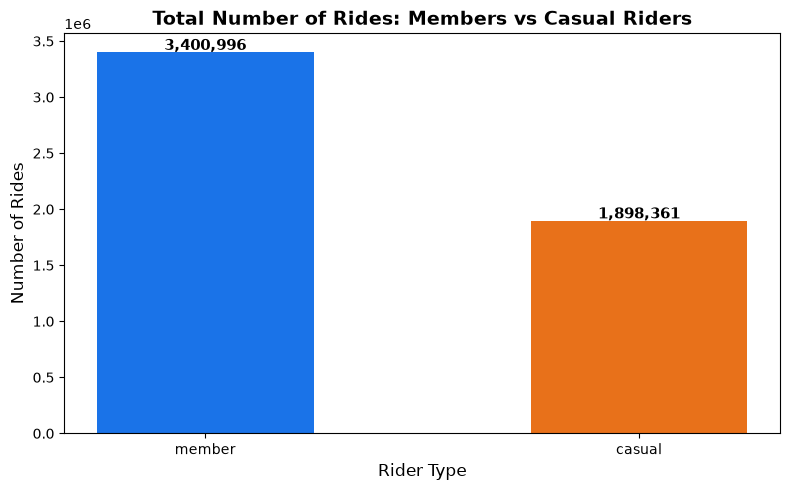

Chart 1 saved!


In [29]:
plt.figure(figsize=(8, 5))

ride_counts = df['member_casual'].value_counts()

colors = ['#1a73e8', '#e8711a']
bars = plt.bar(ride_counts.index, ride_counts.values, color=colors, width=0.5)

plt.title('Total Number of Rides: Members vs Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Rider Type', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)

for bar, value in zip(bars, ride_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'{value:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart1_total_rides.png', dpi=150)
plt.show()
print("Chart 1 saved!")

### Analysis 2: Average Ride Length

Average ride length (minutes):
member_casual
casual    21.15
member    15.37
Name: ride_length, dtype: float64


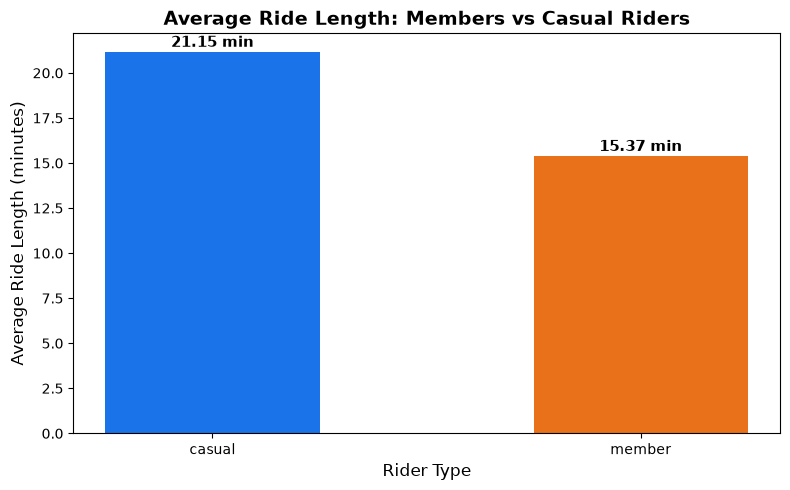

Chart 2 saved!


In [31]:
plt.figure(figsize=(8, 5))

avg_ride = df.groupby('member_casual')['ride_length'].mean().round(2)
print("Average ride length (minutes):")
print(avg_ride)

bars = plt.bar(avg_ride.index, avg_ride.values, color=colors, width=0.5)

plt.title('Average Ride Length: Members vs Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Rider Type', fontsize=12)
plt.ylabel('Average Ride Length (minutes)', fontsize=12)

for bar, value in zip(bars, avg_ride.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{value} min', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart2_avg_ride_length.png', dpi=150)
plt.show()
print("Chart 2 saved!")

### Analysis 3: Rides by Day of Week

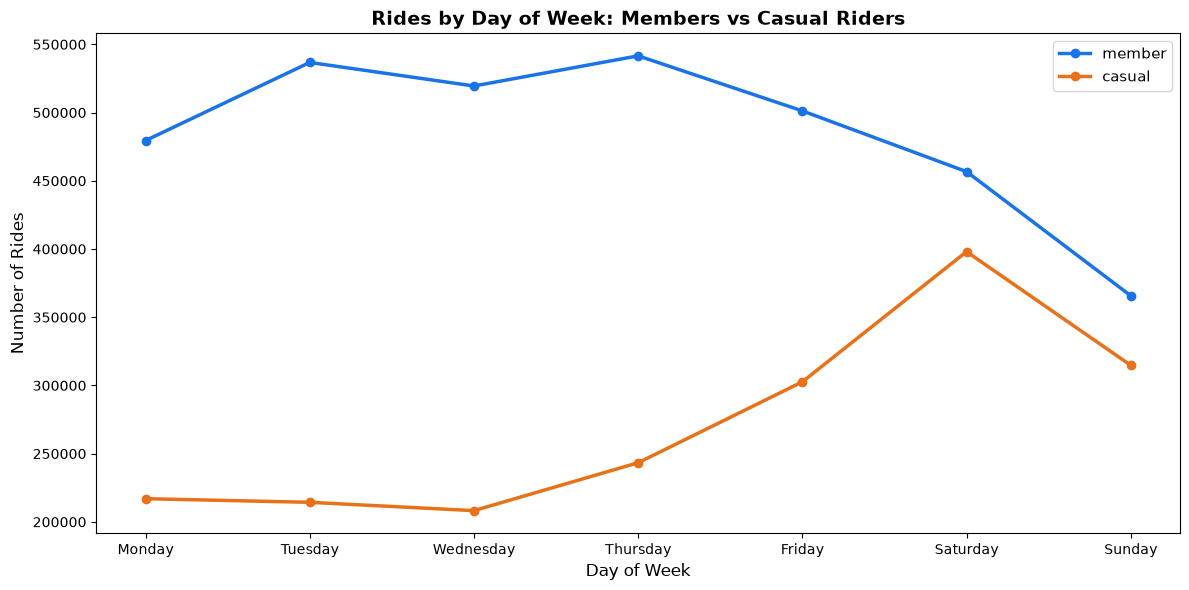

Chart 3 saved!


In [32]:
plt.figure(figsize=(12, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_counts = df.groupby(['member_casual', 'day_of_week']).size().reset_index(name='ride_count')

for rider_type, color in zip(['member', 'casual'], colors):
    data = day_counts[day_counts['member_casual'] == rider_type]
    data = data.set_index('day_of_week').reindex(day_order)
    plt.plot(day_order, data['ride_count'].values, marker='o',
             label=rider_type, color=color, linewidth=2.5)

plt.title('Rides by Day of Week: Members vs Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart3_day_of_week.png', dpi=150)
plt.show()
print("Chart 3 saved!")

### Analysis 4: Monthly Trends

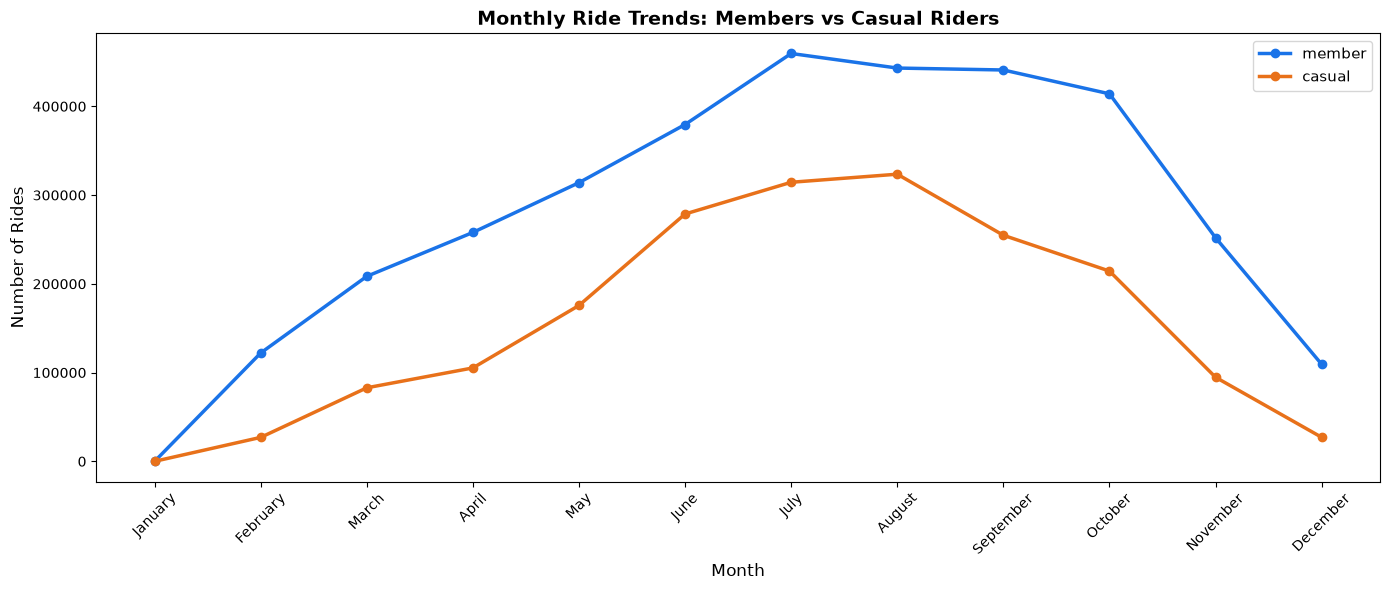

Chart 4 saved!


In [33]:
plt.figure(figsize=(14, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby(['member_casual', 'month']).size().reset_index(name='ride_count')

for rider_type, color in zip(['member', 'casual'], colors):
    data = monthly[monthly['member_casual'] == rider_type]
    data = data.set_index('month').reindex(month_order)
    plt.plot(month_order, data['ride_count'].values, marker='o',
             label=rider_type, color=color, linewidth=2.5)

plt.title('Monthly Ride Trends: Members vs Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart4_monthly_trends.png', dpi=150)
plt.show()
print("Chart 4 saved!")

### Analysis 5: Bike Type Preference

  member_casual  rideable_type  ride_count
0        casual   classic_bike      662800
1        casual  electric_bike     1235561
2        member   classic_bike     1241752
3        member  electric_bike     2159244


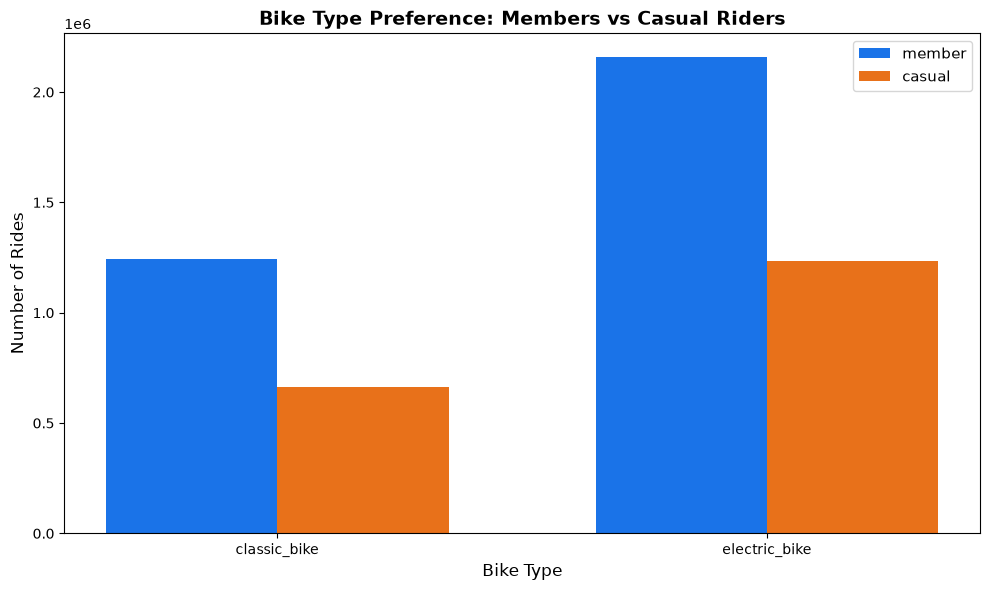

Chart 5 saved!


In [34]:
plt.figure(figsize=(10, 6))

bike_counts = df.groupby(['member_casual', 'rideable_type']).size().reset_index(name='ride_count')
print(bike_counts)

import numpy as np
bike_types = bike_counts['rideable_type'].unique()
x = np.arange(len(bike_types))
width = 0.35

for i, (rider_type, color) in enumerate(zip(['member', 'casual'], colors)):
    data = bike_counts[bike_counts['member_casual'] == rider_type]
    data = data.set_index('rideable_type').reindex(bike_types)
    plt.bar(x + i * width, data['ride_count'].values,
            width, label=rider_type, color=color)

plt.title('Bike Type Preference: Members vs Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Bike Type', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(x + width/2, bike_types)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart5_bike_type.png', dpi=150)
plt.show()
print("Chart 5 saved!")

### Top 10 Stations for Casual Riders

start_station_name
DuSable Lake Shore Dr & Monroe St     30560
Navy Pier                             26939
Streeter Dr & Grand Ave               23161
Michigan Ave & Oak St                 21987
DuSable Lake Shore Dr & North Blvd    19001
Millennium Park                       18609
Shedd Aquarium                        16383
Theater on the Lake                   15437
Dusable Harbor                        15296
Michigan Ave & 8th St                 10947
Name: count, dtype: int64


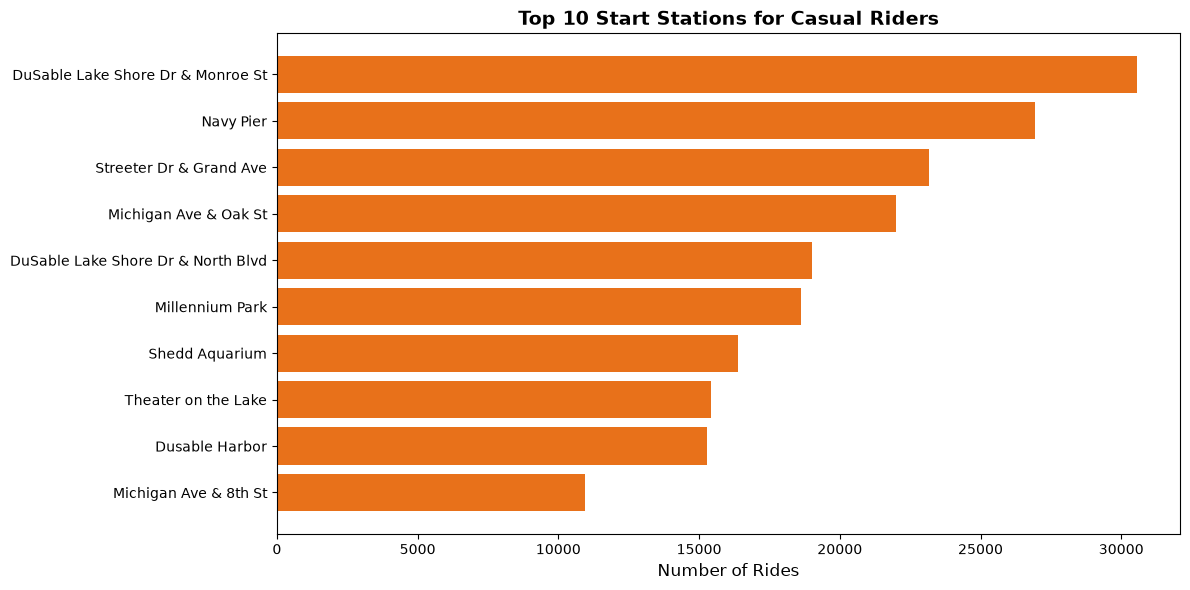

Chart 6 saved!


In [35]:
plt.figure(figsize=(12, 6))

top_stations = df[df['member_casual'] == 'casual']['start_station_name'].value_counts().head(10)
print(top_stations)

plt.barh(top_stations.index, top_stations.values, color='#e8711a')
plt.title('Top 10 Start Stations for Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rides', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart6_top_stations.png', dpi=150)
plt.show()
print("Chart 6 saved!")

### Peak Hours

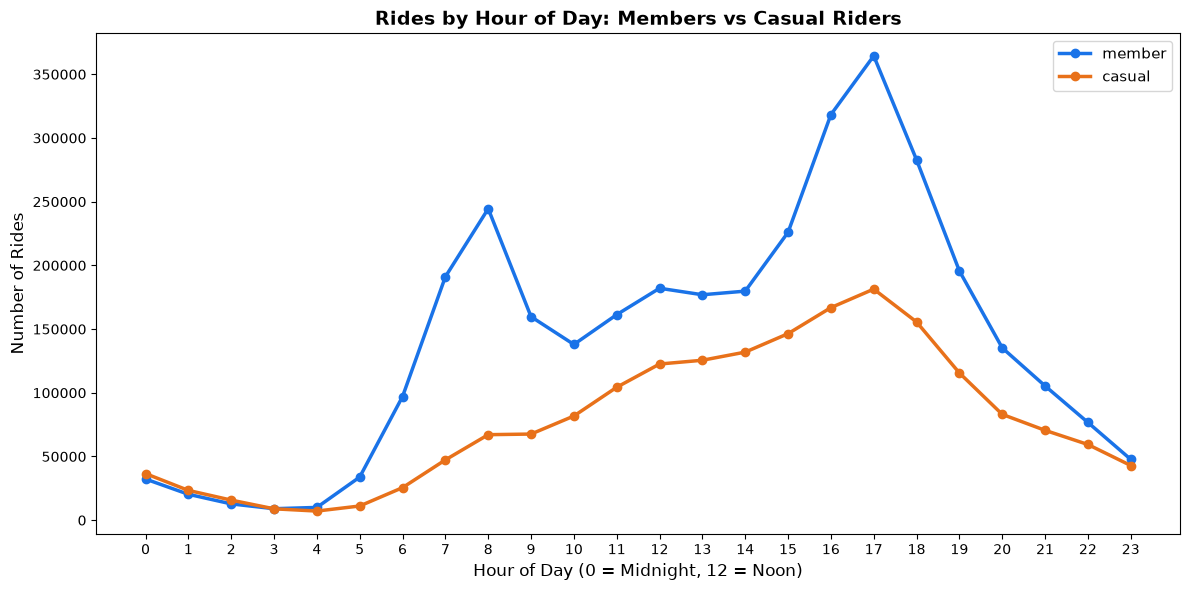

Chart 7 saved!


In [36]:
plt.figure(figsize=(12, 6))

hour_counts = df.groupby(['member_casual', 'hour']).size().reset_index(name='ride_count')

for rider_type, color in zip(['member', 'casual'], ['#1a73e8', '#e8711a']):
    data = hour_counts[hour_counts['member_casual'] == rider_type]
    plt.plot(data['hour'], data['ride_count'], marker='o',
             label=rider_type, color=color, linewidth=2.5)

plt.title('Rides by Hour of Day: Members vs Casual Riders', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Soham\Google Data Analytics\1_Cylcistic_Case_Study\chart7_peak_hours.png', dpi=150)
plt.show()
print("Chart 7 saved!")

## Key Findings

1. **Members ride more but casual riders ride longer**
   - Members: 3,400,996 total rides
   - Casual: 1,898,361 total rides
   - But casual riders ride longer on average — suggesting leisure use

2. **Different days of the week**
   - Members peak on Tuesday and Thursday → weekday commuters
   - Casual riders peak on Saturday → weekend leisure riders

3. **Summer is peak season for casual riders**
   - Both groups peak in July and August
   - Casual riders drop sharply in winter — they ride only for fun
   - Members stay more consistent year round — they depend on bikes

4. **Both groups prefer electric bikes**
   - Good news — no need to change bike fleet for marketing

5. **Casual riders concentrate at specific stations**
   - Top stations are likely near parks, tourist spots, lakefront
   - These are the best locations for targeted marketing

6. **Peak time of the day**
   - Members ride mostly in the morning and evening. Which may be because they ride to and from the work or office
   - While casual riders ride mostly in the  pre evening and evening which are leisure and relaxed hours

## Top 3 Business Recommendations

### Recommendation 1 — Weekend Membership Plan
Casual riders ride most on weekends. A cheaper 
weekend-only membership plan would be attractive 
to them since it matches their riding pattern exactly.

### Recommendation 2 — Summer Marketing Campaign
July and August are when casual riders are most active.
This is the best time to run membership promotions,
discounts, and campaigns — when casual riders are 
already engaged with the service.

### Recommendation 3 — Station Based Marketing
Place membership advertisements and QR code posters
at the top 10 casual rider stations. These riders are
already at those locations — target them there with
offers showing how much they would save with a membership.

### Recommendation 4 — Deploy More Bikes at Peak Hours
   Deploy additional classic and electric bikes during peak hours:
   - Weekday mornings (7AM–9AM) and evenings (5PM–7PM) for member commuters
   - Weekend afternoons for casual leisure riders
   This ensures bike availability when demand is highest, improving 
   experience for both groups and reducing the chance of casual riders 
   leaving due to unavailability.